# Weekly Class AI/ML Advanced 4th & 5th Session Assignments

Dataset's Information:

[titanic.csv](https://www.kaggle.com/competitions/titanic/data?select=train.csv)

|Variable|Definition|Key|
|:---:|:---:|:---|
|survival|Survival|0 = No, 1 = Yes|
|pclass|Ticket class|1 = 1st, 2 = 2nd, 3 = 3rd|
|sex|Sex||
|Age|Age in years||
|sibsp|# of siblings / spouses aboard the Titanic||
|parch|# of parents / children aboard the Titanic||
|ticket|Ticket number||
|fare|Passenger fare||
|cabin|Cabin number||
|embarked|Port of Embarkation|C = Cherbourg, Q = Queenstown, S = Southampton|

,Survived,Pclass,Sex,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,
1,0,3,male,1,0,7.25,S
2,1,1,female,1,0,712.833,C
3,1,3,female,0,0,7.925,S
4,1,1,female,1,0,53.1,S
5,0,3,male,0,0,08.05,S


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Fare,891,248,08.05,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Survived  891 non-null    int64 
 1   Pclass    891 non-null    int64 
 2   Sex       891 non-null    object
 3   SibSp     891 non-null    int64 
 4   Parch     891 non-null    int64 
 5   Fare      891 non-null    object
 6   Embarked  889 non-null    object
dtypes: int64(4), object(3)
memory usage: 55.7+ KB


None

,0
Survived,0
Pclass,0
Sex,0
SibSp,0
Parch,0
Fare,0
Embarked,2


array([[<Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>],
       [<Axes: title={'center': 'SibSp'}>,
        <Axes: title={'center': 'Parch'}>]], dtype=object)

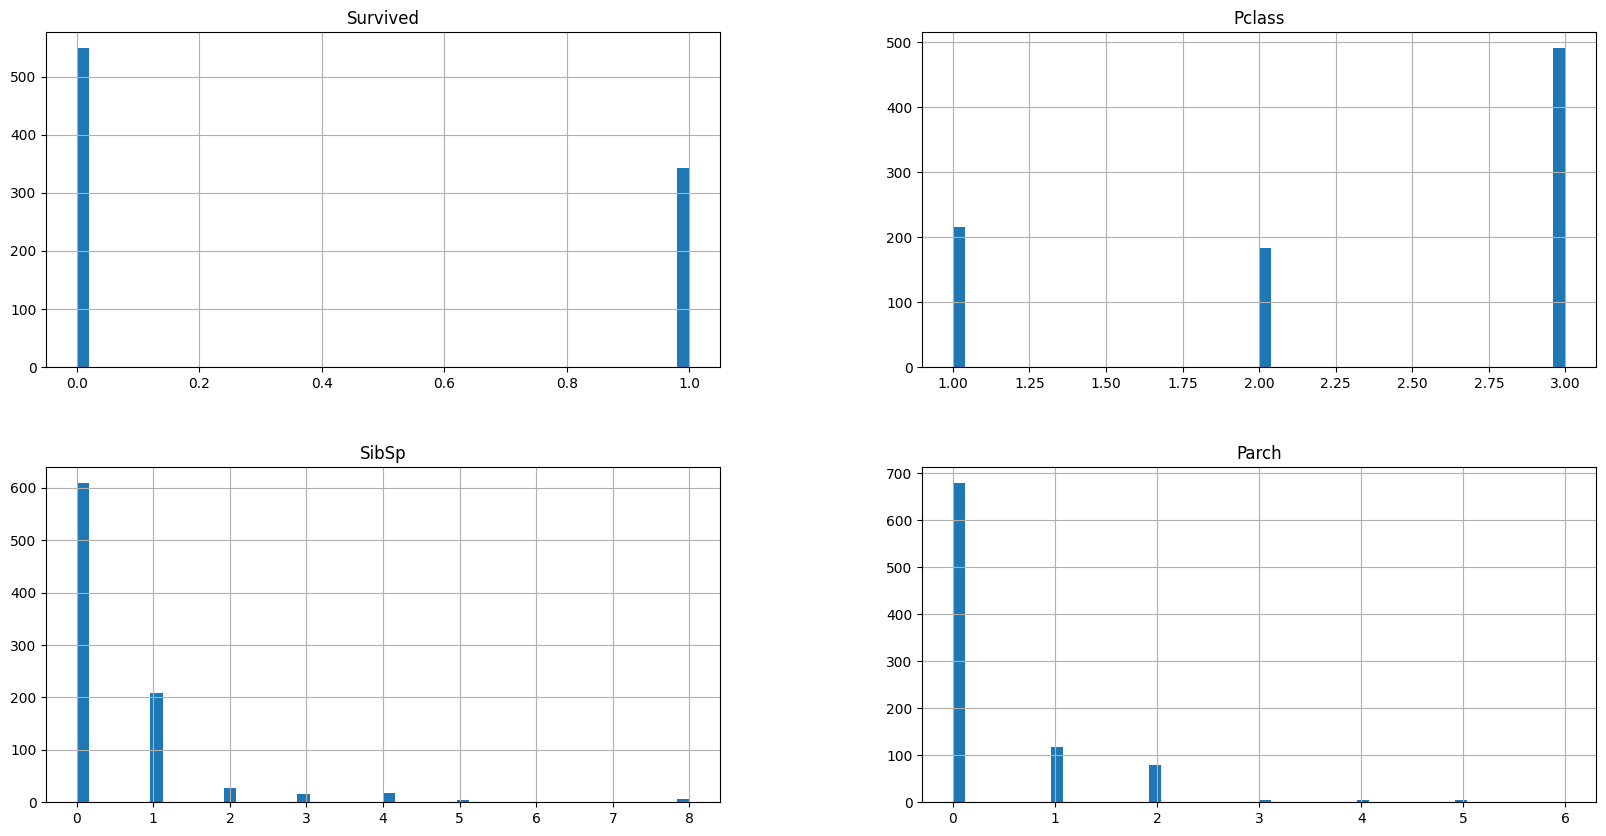

In [1]:
import pandas as pd
import warnings

pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

df = pd.read_csv('titanic.csv', index_col='PassengerId')
df.drop(['Name', 'Age', 'Ticket', 'Cabin'], axis=1, inplace=True)

display(df.head())
display(df.describe(include='all').T)
display(df.info())
display(df.isnull().sum())
df.hist(bins=50, figsize=(20,10))

In [2]:
def parse_fare(val):
    s = str(val).strip()
    if s.count('.') > 1:
        parts = s.split('.')
        return float(''.join(parts[:-1]) + '.' + parts[-1])
    return float(s)

df['Fare'] = df['Fare'].apply(parse_fare)

In [3]:
# Pisahkan data sebelum preprocessing
from sklearn.model_selection import train_test_split

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'X_train: {X_train.shape}\nX_test: {X_test.shape}')
print(f'y_train: {y_train.shape}\ny_test: {y_test.shape}\n')
print(y_train.value_counts(normalize=True), '\n')
print(y_test.value_counts(normalize=True))

X_train: (712, 6)
X_test: (179, 6)
y_train: (712,)
y_test: (179,)

Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64 

Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


In [4]:
# Data Preprocessing menggunakan Sci-kit Learn Pipeline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, RobustScaler

pipeline_categoric = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

pipeline_numeric = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Tambahan
    ('scaler', MinMaxScaler())
])

pipeline_fare = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # Tambahan
    ('scaler', RobustScaler())
])

In [5]:
# Declare ColumnTransformer
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('pipeline_categoric', pipeline_categoric, ['Pclass', 'Sex', 'Embarked']),
        ('pipeline_numeric', pipeline_numeric, ['SibSp', 'Parch']),
        ('pipeline_fare', pipeline_fare, ['Fare'])
    ],
    remainder='passthrough'
)

In [6]:
print(df['Fare'].dtype)
print(df['Fare'].head(10))

float64
PassengerId
1       7.2500
2     712.8330
3       7.9250
4      53.1000
5       8.0500
6       8.4583
7     518.6250
8      21.0750
9      11.1333
10    300.7080
Name: Fare, dtype: float64


In [7]:
# Create the core Pipeline + model selection
from sklearn.model_selection import KFold, cross_val_score

# Import classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Declare models
models = {
    'Logistic Regression': LogisticRegression(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

# Save the results for next cell
results = {
    'model': [],
    'avg_scores': [],
    'std_scores': []
}

# Model Selection
for model_name, model in models.items():
    # The core Pipeline
    pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ]
    )

    # Calculate the cross-validation scores
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='accuracy')

    # Saving the results
    results['model'].append(model_name)
    results['avg_scores'].append(cv_scores.mean())
    results['std_scores'].append(cv_scores.std())

    # Check the results
    print(f'Cross-Validation results for: {model_name}')
    print(f'{'='*48}\nScores: {cv_scores}')
    print(f'Average Score: {cv_scores.mean()}')
    print(f'Score\'s std: {cv_scores.std()}\n')

Cross-Validation results for: Logistic Regression
Scores: [0.74825175 0.75524476 0.78169014 0.79577465 0.86619718]
Average Score: 0.7894316950654978
Score's std: 0.042089523017247665

Cross-Validation results for: K-Nearest Neighbors
Scores: [0.78321678 0.82517483 0.78873239 0.83098592 0.82394366]
Average Score: 0.8104107160445189
Score's std: 0.02016887696255982

Cross-Validation results for: Support Vector Machine
Scores: [0.76223776 0.76223776 0.77464789 0.79577465 0.86619718]
Average Score: 0.7922190485570767
Score's std: 0.03896641487907737

Cross-Validation results for: Decision Tree
Scores: [0.74825175 0.81118881 0.8028169  0.83802817 0.84507042]
Average Score: 0.8090712104796612
Score's std: 0.03428427136924138

Cross-Validation results for: Random Forest
Scores: [0.77622378 0.7972028  0.8028169  0.81690141 0.81690141]
Average Score: 0.8020092583472864
Score's std: 0.015047908251946842

Cross-Validation results for: XGBoost
Scores: [0.76223776 0.7972028  0.79577465 0.82394366 0

In [8]:
# Show model benchmarking as DataFrame
pd.DataFrame(results, index=results['model']).drop('model', axis=1).sort_values(by='avg_scores', ascending=False)

# kita pilih Random Forest

,avg_scores,std_scores
K-Nearest Neighbors,0.810411,0.020169
Decision Tree,0.809071,0.034284
XGBoost,0.807663,0.032344
Random Forest,0.802009,0.015048
Support Vector Machine,0.792219,0.038966
Logistic Regression,0.789432,0.042090


In [9]:
# Import RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Re-declare core Pipeline
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(random_state=42))
    ]
)

# Define hyperparameter combination (search space)
parameter = {
    'model__n_estimators': [100, 200, 300, 400, 500],
    'model__max_depth': [None, 10, 20, 30, 40],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

# Setup RandomizedSearchCV Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=parameter,
    n_iter=20,
    cv=kf,
    scoring='accuracy',
    verbose=1,
    random_state=42,
    return_train_score=True
    )

# Model training
model.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('pipeline_categoric',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encoder',
                                                                                                OneHotEncoder(handle_unknown='ignore',
                                                                                                              sparse_output=False))]),
                                                                               ['Pclass',
                                                                                'Sex',
                                                                                'Emb...
                                                                               ['Fare'])])),
                                             ('model',
                                              RandomForestClassifier(random_state=42))]),
                   n_iter=20,
                   param_distributions={'model__max_depth': [None, 10, 20, 30,
                                                             40],
                                        'model__max_features': ['sqrt', 'log2'],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300,
                                                                400, 500]},
                   random_state=42, return_train_score=True, scoring='accuracy',
                   verbose=1)

In [10]:
# Check Hyperparameter Tuning result
pd.DataFrame(model.cv_results_).sort_values(by='rank_test_score').head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_estimators,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
13,0.204545,0.007269,0.020236,0.000347,100,5,1,log2,10,"{'model__n_estimators': 100, 'model__min_sampl...",0.790210,0.811189,0.795775,0.830986,0.859155,0.817463,0.025194,1,0.910369,0.903339,0.914035,0.896491,0.900000,0.904847,0.006488
16,0.401239,0.019897,0.029550,0.001224,200,5,1,log2,20,"{'model__n_estimators': 200, 'model__min_sampl...",0.804196,0.818182,0.795775,0.809859,0.852113,0.816025,0.019468,2,0.908612,0.910369,0.921053,0.903509,0.907018,0.910112,0.005919
5,0.844625,0.297118,0.060666,0.016245,300,5,2,log2,10,"{'model__n_estimators': 300, 'model__min_sampl...",0.790210,0.825175,0.788732,0.809859,0.859155,0.814626,0.026013,3,0.889279,0.885764,0.892982,0.871930,0.882456,0.884482,0.007191
18,0.426575,0.022468,0.033726,0.005310,200,2,4,log2,None,"{'model__n_estimators': 200, 'model__min_sampl...",0.755245,0.797203,0.795775,0.823944,0.859155,0.806264,0.034366,4,0.852373,0.855888,0.859649,0.850877,0.861404,0.856038,0.004048
9,0.867101,0.299532,0.057910,0.018718,300,10,2,sqrt,30,"{'model__n_estimators': 300, 'model__min_sampl...",0.776224,0.797203,0.788732,0.809859,0.859155,0.806235,0.028643,5,0.876977,0.869947,0.877193,0.859649,0.870175,0.870788,0.006395


In [11]:
# prefer joblib for sklearn models
import joblib

# Save the model as 'model.joblib'
joblib.dump(model, 'model.joblib')

['model.joblib']